In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('data.csv')
print(df.head())

   Hours_Studied  Exam_Score
0            1.0          32
1            1.2          35
2            1.5          38
3            1.8          42
4            2.0          45


In [3]:
# Convert data to NumPy arrays
X = df[['Hours_Studied']].values
y = df['Exam_Score'].values

# Create and train the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [4]:
# Slope and Intercept
print('Slope (m):', model.coef_[0])
print('Intercept (c):', model.intercept_)

# Multiple prediction examples using NumPy
test_inputs = np.array([[2.0], [4.5], [6.0], [9.0]])
predicted_outputs = model.predict(test_inputs)

print('\n--- Prediction Examples ---')
for val, pred in zip(test_inputs, predicted_outputs):
    print(f"Hours Studied: {val[0]} -> Predicted Exam Score: {pred:.2f}")

Slope (m): 8.935229675187394
Intercept (c): 27.00365173938112

--- Prediction Examples ---
Hours Studied: 2.0 -> Predicted Exam Score: 44.87
Hours Studied: 4.5 -> Predicted Exam Score: 67.21
Hours Studied: 6.0 -> Predicted Exam Score: 80.62
Hours Studied: 9.0 -> Predicted Exam Score: 107.42


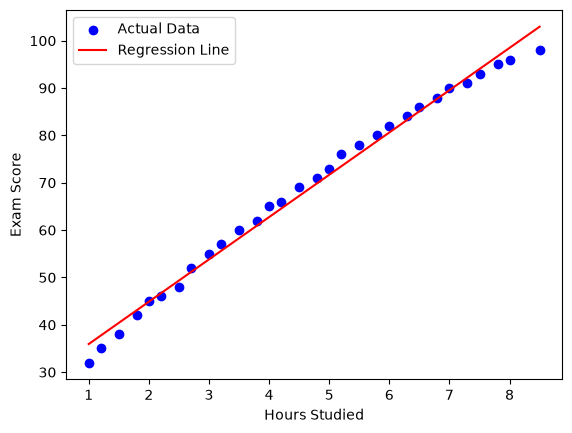

In [5]:
# Plot data and regression line
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

In [6]:
# R2 Score (Accuracy of Regression Fit)
y_pred = model.predict(X)
print('R2 Score (Regression Fit Accuracy):', r2_score(y, y_pred))

R2 Score (Regression Fit Accuracy): 0.9909750400451636


Classification Accuracy: 0.9666666666666667


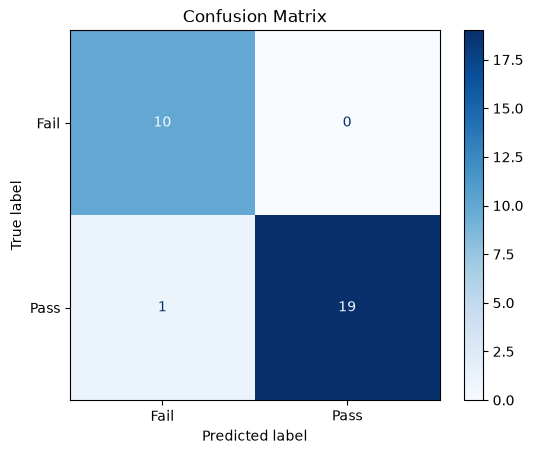

In [7]:
# Use NumPy np.where to convert to binary classes
y_actual_class = np.where(y >= 60, 1, 0)
y_pred_class = np.where(y_pred >= 60, 1, 0)

# Accuracy Score
accuracy = accuracy_score(y_actual_class, y_pred_class)
print('Classification Accuracy:', accuracy)

# Plot Confusion Matrix
cm = confusion_matrix(y_actual_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()